In [1]:
path_to_dataset = "drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-DB"

In [13]:
import os
import pandas as pd

# Map short codes to full emotion labels
label_map = {
    "ang": "angry",
    "hap": "happy",
    "neu": "neutral",
    "sad": "sad",
    "fea": "fear"
}

# Build dataframe
filepaths, labels, speakers = [], [], []

for fname in os.listdir(path_to_dataset):
    if fname.endswith(".wav"):
        filepath = os.path.join(path_to_dataset, fname)
        label_code = fname.split("_")[-1].replace(".wav","")
        label = label_map[label_code]
        speaker = "_".join(fname.split("_")[:2])  # first two parts = speaker ID
        filepaths.append(filepath)
        labels.append(label)
        speakers.append(speaker)

df = pd.DataFrame({"filepath": filepaths, "label": labels, "speaker": speakers})

print("✅ Dataset Loaded")
print(df.head())
print("\nUnique speakers:", df['speaker'].nunique())
print("Class counts:\n", df['label'].value_counts())


✅ Dataset Loaded
                                            filepath    label speaker
0  drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-D...  neutral   01_07
1  drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-D...      sad   02_07
2  drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-D...  neutral   01_09
3  drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-D...    angry   01_01
4  drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-D...  neutral   02_06

Unique speakers: 209
Class counts:
 label
neutral    209
sad        209
happy      209
angry      199
fear       110
Name: count, dtype: int64


/tmp/ipython-input-2518441917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=df, palette="mako", order=df['label'].value_counts().index)


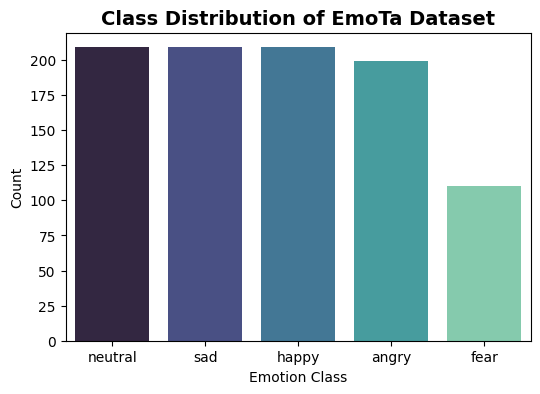

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, palette="mako", order=df['label'].value_counts().index)
plt.title("Class Distribution of EmoTa Dataset", fontsize=14, weight="bold")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.show()


In [15]:
class_counts = df['label'].value_counts().reset_index()
class_counts.columns = ["Emotion", "Count"]
print("📋 Class Distribution Table")
print(class_counts.to_string(index=False))


📋 Class Distribution Table
Emotion  Count
neutral    209
    sad    209
  happy    209
  angry    199
   fear    110


/tmp/ipython-input-2387738490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Emotion", y="Unique Speakers", data=speaker_counts, palette="rocket")


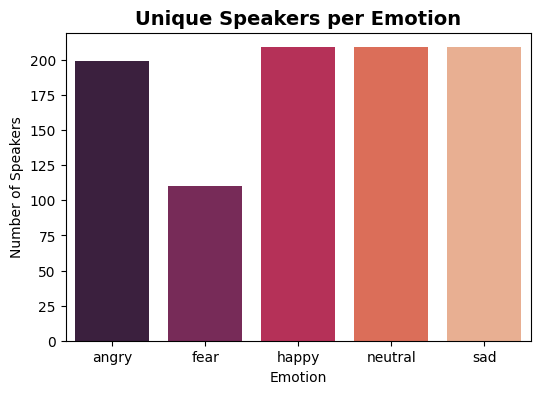

🎙️ Speakers per Emotion
Emotion  Unique Speakers
  angry              199
   fear              110
  happy              209
neutral              209
    sad              209


In [16]:
speaker_counts = df.groupby("label")['speaker'].nunique().reset_index()
speaker_counts.columns = ["Emotion", "Unique Speakers"]

plt.figure(figsize=(6,4))
sns.barplot(x="Emotion", y="Unique Speakers", data=speaker_counts, palette="rocket")
plt.title("Unique Speakers per Emotion", fontsize=14, weight="bold")
plt.ylabel("Number of Speakers")
plt.show()

print("🎙️ Speakers per Emotion")
print(speaker_counts.to_string(index=False))


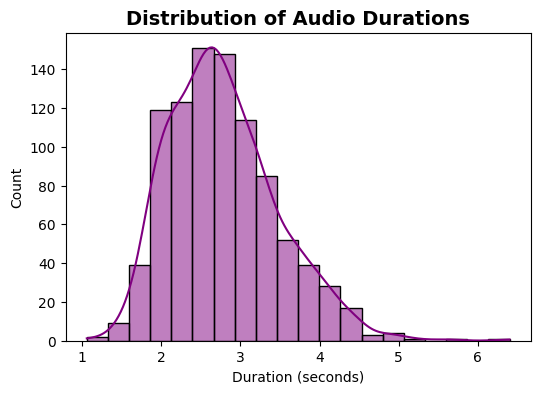

In [17]:
import librosa

# Compute durations for each file
durations = []
for fp in df["filepath"]:
    y, sr = librosa.load(fp, sr=None)
    durations.append(len(y)/sr)

df["duration_sec"] = durations

# Plot histogram of durations
plt.figure(figsize=(6,4))
sns.histplot(df["duration_sec"], bins=20, kde=True, color="purple")
plt.title("Distribution of Audio Durations", fontsize=14, weight="bold")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-2865192327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="duration_sec", data=df, palette="flare")


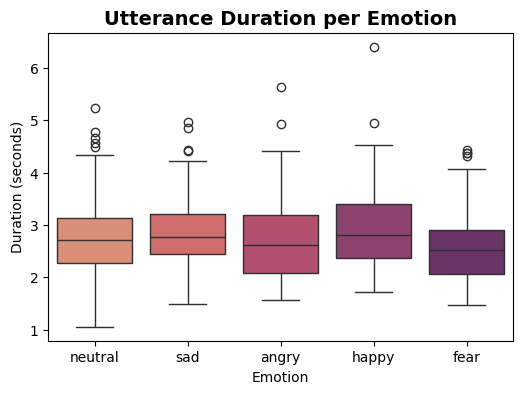

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="duration_sec", data=df, palette="flare")
plt.title("Utterance Duration per Emotion", fontsize=14, weight="bold")
plt.xlabel("Emotion")
plt.ylabel("Duration (seconds)")
plt.show()

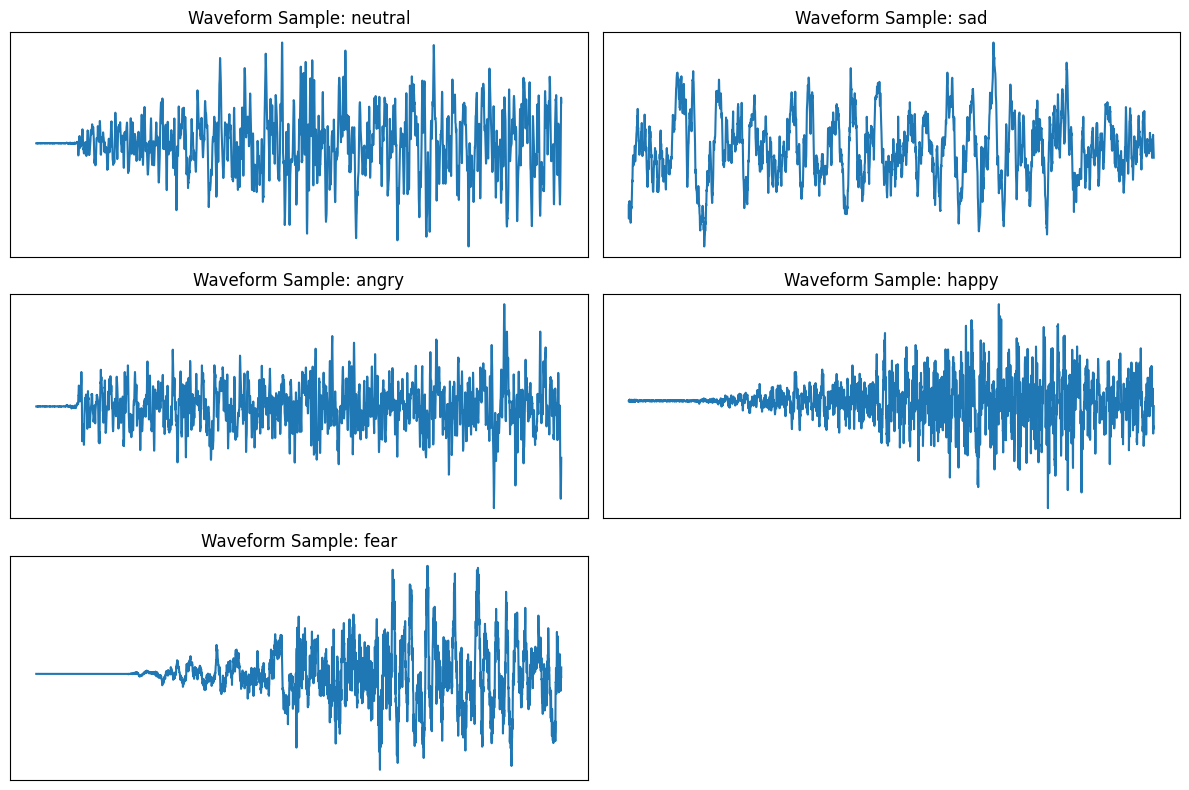

In [21]:
import random

# Plot 1 random waveform for each emotion
plt.figure(figsize=(12,8))
unique_emotions = df['label'].unique()

for i, emotion in enumerate(unique_emotions):
    sample = random.choice(df[df['label'] == emotion]['filepath'].tolist())
    y, sr = librosa.load(sample, sr=16000)
    plt.subplot(3, 2, i+1)  # 3x2 grid for up to 5 emotions
    plt.plot(y[:4000])  # plot first 4000 samples (~0.25 sec for clarity)
    plt.title(f"Waveform Sample: {emotion}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()
